# Keyword analysis

In [1]:
import polars as pl
import polars_corpus as plc


In [2]:
pl.Config.set_tbl_rows(25)
pl.Config.set_float_precision(3)

polars.config.Config

In [3]:
# bnc = pl.scan_parquet("bnc.parquet").set_sorted("file_id")
# speakers = pl.scan_parquet("bnc-speakers.parquet")
#
# speakers = speakers.filter(pl.col("sex").is_in(["m", "f"]))
# speakers.group_by("sex").len()
#
# bnc = (
#     bnc.filter(pl.col("text_type") == "CONVRSN")
#     .join(speakers, on="speaker_id", how="inner")
#     .with_columns(pl.col("token").str.to_lowercase().alias("norm"))
#)

amalgum = pl.read_parquet('amalgum.parquet')

Stefanowitsch (2020), pp. 378–380

In [4]:
# male_keywords = plc.keywords(
#     target = bnc.filter(pl.col('sex')=='m'),
#     reference= bnc.filter(pl.col('sex')=='f'),
#     method='ll',
#     expr=pl.col('token').str.to_lowercase()
# ).select('token','target_df','LogLik').collect(engine="streaming")

academic_keywords = plc.keywords(
    target = amalgum.filter(pl.col('text_type')=='academic'),
    reference=  amalgum.filter(pl.col('text_type')!='academic'),
    method='ll',
    expr=pl.col('token').str.to_lowercase()
).select('token','target_df','LogLik')



In [5]:
academic_keywords.head(10)

token,target_df,LogLik
str,u32,f64
"""data""",269,2901.020
"""study""",412,2738.682
"""of""",746,2555.273
"""al.""",222,2400.650
"""studies""",322,2014.972
"""et""",223,1901.530
"""model""",240,1845.527
"""results""",352,1690.592
"""analysis""",277,1628.653


<Axes: >

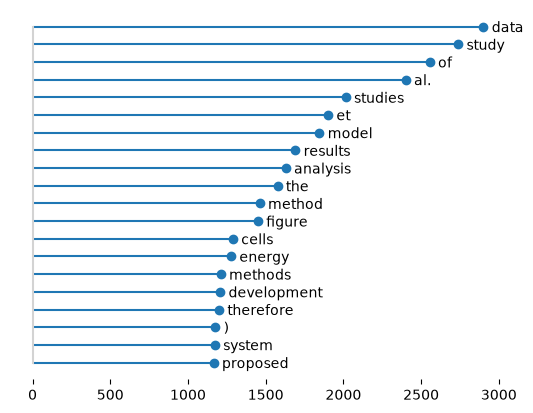

In [6]:
plc.keyword_plot(academic_keywords, 'token', 'LogLik', top_k=20, descending=True)

/var/folders/fd/srnndh49795gdvrqxj_q0scm0000gr/T/ipykernel_65544/668011609.py:1: UserWarning: dropped 3 of 562,642 rows of the target corpus holding a null 'token'
  academic_keygrams = plc.keywords(
/var/folders/fd/srnndh49795gdvrqxj_q0scm0000gr/T/ipykernel_65544/668011609.py:1: UserWarning: dropped 3 of 3,287,787 rows of the reference corpus holding a null 'token'
  academic_keygrams = plc.keywords(


<Axes: >

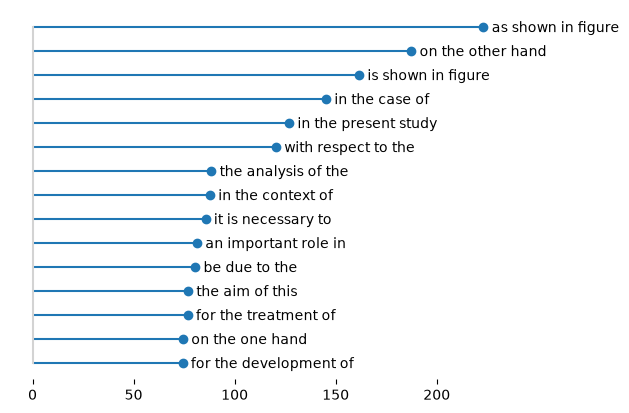

In [11]:
academic_keygrams = plc.keywords(
    target=amalgum.filter(pl.col('text_type') == 'academic'),
    reference=amalgum.filter(pl.col('text_type') != 'academic'),
    method='ll',
    min_target_tf=10,
    expr=plc.ngrams(4, 'token', as_str=True).str.to_lowercase()
).select('token', 'target_df', 'LogLik').filter(plc.is_letters('token', allow_spaces=True))

plc.keyword_plot(academic_keygrams, 'token', 'LogLik', top_k=15, descending=True)
#academic_keygrams

Lijffijt et al. (2016)

In [8]:
academic_keywords = plc.keywords(
    target = amalgum.filter(pl.col('file_type')=='whow'),
    reference=  amalgum.filter(pl.col('file_type')!='whow'),
    method='ttest',
    expr=pl.col('token').str.to_lowercase()
)

ColumnNotFoundError: unable to find column "file_type"; valid columns: ["token", "pos", "lemma", "sentence_tag", "file_id", "text_type"]

<Axes: >

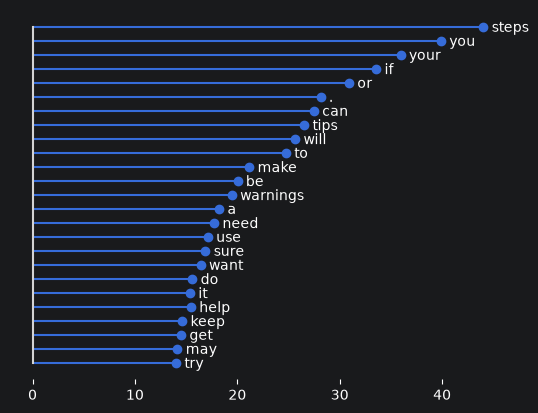

In [43]:
plc.keyword_plot(academic_keywords, 'token', 'stat', top_k=25, descending=True)

In [37]:
len(amalgum), len(amalgum.drop_nulls())

(3850429, 3850429)